In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import glob
from skimage.feature import ORB
from skimage import io, color, img_as_ubyte
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

Libraries imported successfully!
OpenCV version: 4.12.0


In [9]:
def load_dataset(data_dir):
    """Load dataset from all country directories - adapted from YOLO finetuning"""
    dataset = []
    country_dirs = [d for d in os.listdir(data_dir) if d.startswith('country_')]
    
    for country_dir in country_dirs:
        country_path = os.path.join(data_dir, country_dir)
        images_path = os.path.join(country_path, 'images')
        labels_path = os.path.join(country_path, 'labels')

        image_files = glob.glob(os.path.join(images_path, '*.jpg'))

        for image_file in image_files:
            base_name = os.path.splitext(os.path.basename(image_file))[0]
            label_file = os.path.join(labels_path, f"{base_name}.txt")

            if os.path.exists(label_file):
                bboxes = []
                with open(label_file, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if line:
                            parts = line.split()
                            if len(parts) == 5:
                                class_id = int(parts[0])
                                x_center = float(parts[1])
                                y_center = float(parts[2])
                                width = float(parts[3])
                                height = float(parts[4])
                                bboxes.append({
                                    'class_id': class_id,
                                    'x_center': x_center,
                                    'y_center': y_center,
                                    'width': width,
                                    'height': height,
                                })

                dataset.append({
                    'image_path': image_file,
                    'label_path': label_file,
                    'bboxes': bboxes,
                    'country': country_dir
                })

    return dataset

# Load dataset
data_dir = "data"
dataset = load_dataset(data_dir)

# Define class names (same as YOLO finetuning)
class_names = {
    0: 'Pothole',
    1: 'Alligator Crack',
    2: 'Transverse Crack',
    3: 'Longitudinal Crack',
}

# Filter samples with bounding boxes
samples_with_bboxes = [sample for sample in dataset if len(sample['bboxes']) > 0]

print(f"Total samples: {len(dataset)}")
print(f"Samples with annotations: {len(samples_with_bboxes)}")
print(f"Ready for ORB feature extraction!")

Total samples: 6039
Samples with annotations: 6039
Ready for ORB feature extraction!


In [10]:
def sample_images(dataset, n_samples=12, class_filter=None):
    """Sample images from dataset, optionally filter by damage class"""
    if class_filter is not None:
        # Filter by specific damage class
        filtered_samples = []
        for sample in dataset:
            for bbox in sample['bboxes']:
                if bbox['class_id'] == class_filter:
                    filtered_samples.append(sample)
                    break  # Only add sample once even if multiple bboxes of same class
        available_samples = filtered_samples
        print(f"Found {len(available_samples)} samples with {class_names[class_filter]} damage")
    else:
        available_samples = dataset
        print(f"Sampling from all {len(available_samples)} samples")
    
    # Sample random images
    if len(available_samples) < n_samples:
        print(f"Warning: Only {len(available_samples)} samples available, sampling all")
        return available_samples
    
    sampled = random.sample(available_samples, n_samples)
    return sampled

def extract_orb_features(image_path, n_keypoints=500):
    """Extract ORB features from an image using scikit-image"""
    try:
        # Load image
        image = io.imread(image_path)
        
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            gray_image = color.rgb2gray(image)
        else:
            gray_image = image
        
        # Convert to uint8 format (required for ORB)
        gray_image = img_as_ubyte(gray_image)
        
        # Initialize ORB detector
        orb = ORB(n_keypoints=n_keypoints, fast_threshold=0.05)
        
        # Detect keypoints and extract descriptors
        orb.detect_and_extract(gray_image)
        
        keypoints = orb.keypoints
        descriptors = orb.descriptors
        
        return {
            'keypoints': keypoints,
            'descriptors': descriptors,
            'n_keypoints': len(keypoints) if keypoints is not None else 0,
            'image_shape': gray_image.shape,
            'original_image': image,
            'gray_image': gray_image
        }
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Sample images from different damage types
print("Sampling images for ORB feature extraction...")

# Sample from each damage class
samples_by_class = {}
for class_id, class_name in class_names.items():
    samples_by_class[class_id] = sample_images(samples_with_bboxes, n_samples=3, class_filter=class_id)

# Also sample some general images (mixed classes)
mixed_samples = sample_images(samples_with_bboxes, n_samples=6)

print(f"\nSampled images:")
for class_id, samples in samples_by_class.items():
    print(f"  {class_names[class_id]}: {len(samples)} images")
print(f"  Mixed classes: {len(mixed_samples)} images")

Sampling images for ORB feature extraction...
Found 1817 samples with Pothole damage
Found 2934 samples with Alligator Crack damage
Found 2723 samples with Transverse Crack damage
Found 3082 samples with Longitudinal Crack damage
Sampling from all 6039 samples

Sampled images:
  Pothole: 3 images
  Alligator Crack: 3 images
  Transverse Crack: 3 images
  Longitudinal Crack: 3 images
  Mixed classes: 6 images


In [11]:
# Extract ORB features from sampled images
print("Extracting ORB features...")

# Extract features from class-specific samples
orb_results_by_class = {}
for class_id, samples in samples_by_class.items():
    class_name = class_names[class_id]
    print(f"\nProcessing {class_name} samples...")
    
    class_results = []
    for i, sample in enumerate(samples):
        print(f"  Processing {class_name} image {i+1}/{len(samples)}")
        features = extract_orb_features(sample['image_path'])
        if features is not None:
            features['sample_info'] = sample
            features['class_name'] = class_name
            features['class_id'] = class_id
            class_results.append(features)
    
    orb_results_by_class[class_id] = class_results
    print(f"  Successfully extracted features from {len(class_results)} {class_name} images")

# Extract features from mixed samples
print(f"\nProcessing mixed class samples...")
mixed_orb_results = []
for i, sample in enumerate(mixed_samples):
    print(f"  Processing mixed image {i+1}/{len(mixed_samples)}")
    features = extract_orb_features(sample['image_path'])
    if features is not None:
        features['sample_info'] = sample
        # Get primary damage class (first bbox)
        primary_class_id = sample['bboxes'][0]['class_id']
        features['class_name'] = class_names[primary_class_id]
        features['class_id'] = primary_class_id
        mixed_orb_results.append(features)

print(f"Successfully extracted features from {len(mixed_orb_results)} mixed images")

# Summary statistics
print(f"\n=== ORB Feature Extraction Summary ===")
total_images = sum(len(results) for results in orb_results_by_class.values()) + len(mixed_orb_results)
total_keypoints = 0

for class_id, results in orb_results_by_class.items():
    class_keypoints = sum(r['n_keypoints'] for r in results)
    total_keypoints += class_keypoints
    print(f"{class_names[class_id]}: {len(results)} images, {class_keypoints} total keypoints")

mixed_keypoints = sum(r['n_keypoints'] for r in mixed_orb_results)
total_keypoints += mixed_keypoints
print(f"Mixed samples: {len(mixed_orb_results)} images, {mixed_keypoints} total keypoints")

print(f"\nOverall: {total_images} images processed, {total_keypoints} total keypoints detected")
print(f"Average keypoints per image: {total_keypoints/total_images:.1f}")

Extracting ORB features...

Processing Pothole samples...
  Processing Pothole image 1/3


  Processing Pothole image 2/3
  Processing Pothole image 3/3
  Processing Pothole image 3/3
  Successfully extracted features from 3 Pothole images

Processing Alligator Crack samples...
  Processing Alligator Crack image 1/3
  Successfully extracted features from 3 Pothole images

Processing Alligator Crack samples...
  Processing Alligator Crack image 1/3
  Processing Alligator Crack image 2/3
  Processing Alligator Crack image 2/3
  Processing Alligator Crack image 3/3
  Processing Alligator Crack image 3/3
  Successfully extracted features from 3 Alligator Crack images

Processing Transverse Crack samples...
  Processing Transverse Crack image 1/3
  Successfully extracted features from 3 Alligator Crack images

Processing Transverse Crack samples...
  Processing Transverse Crack image 1/3
  Processing Transverse Crack image 2/3
  Processing Transverse Crack image 2/3
  Processing Transverse Crack image 3/3
  Processing Transverse Crack image 3/3
  Successfully extracted features f


=== Pothole ORB Features ===


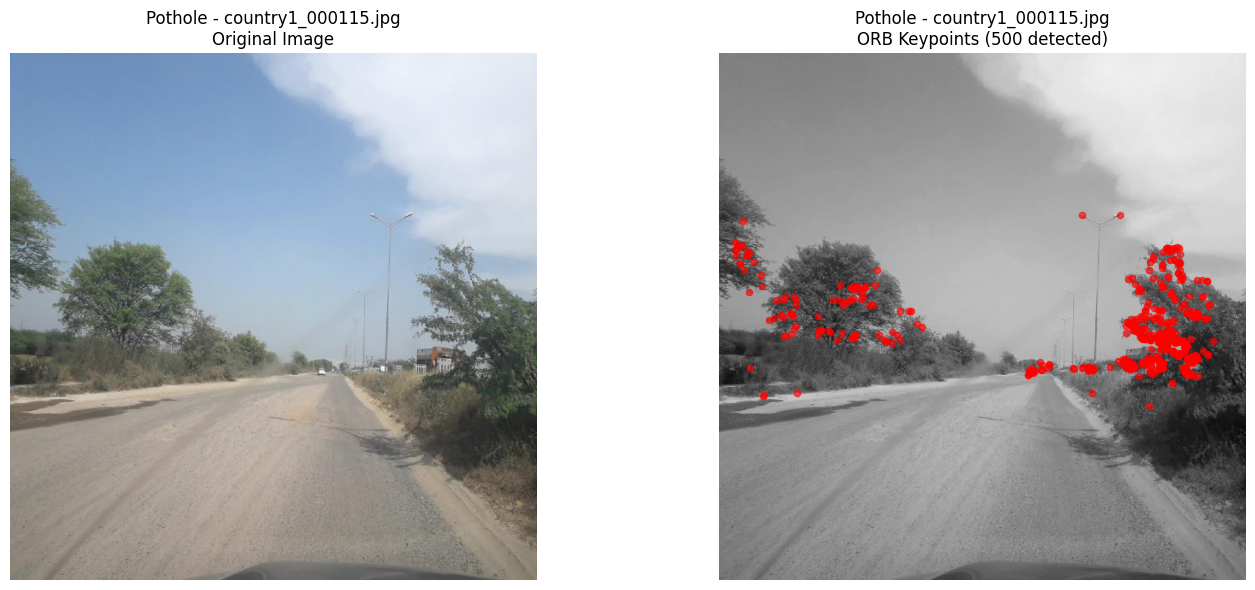

  Image: country1_000115.jpg
  Keypoints detected: 500
  Image shape: (720, 720)
  Descriptor shape: (500, 256)



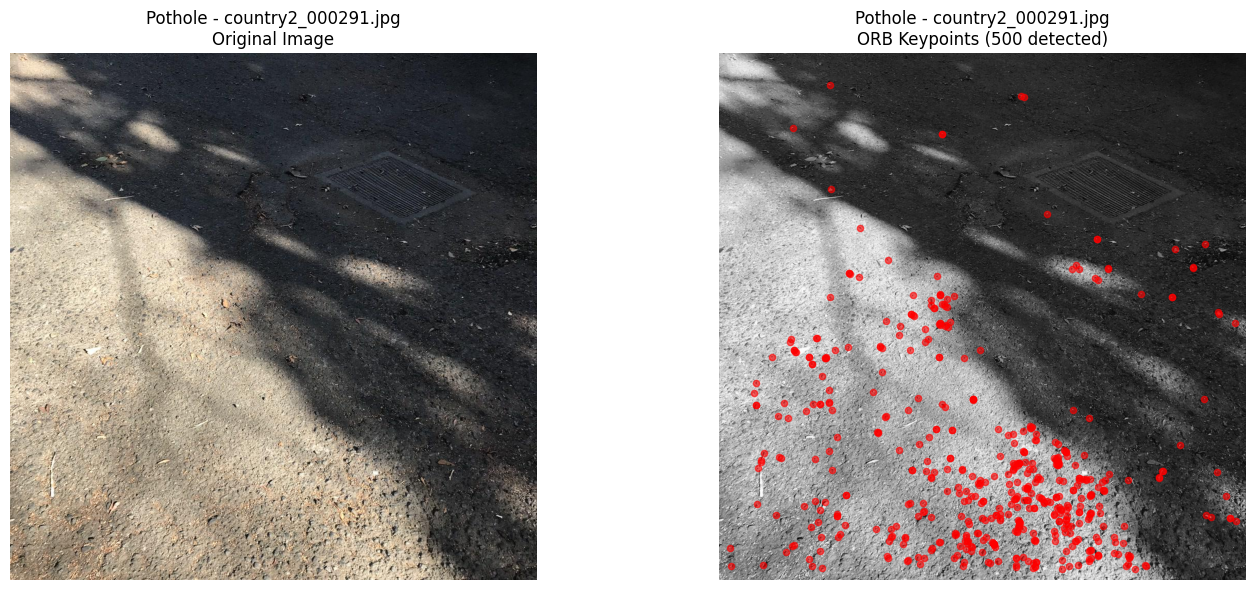

  Image: country2_000291.jpg
  Keypoints detected: 500
  Image shape: (1024, 1024)
  Descriptor shape: (500, 256)


=== Alligator Crack ORB Features ===


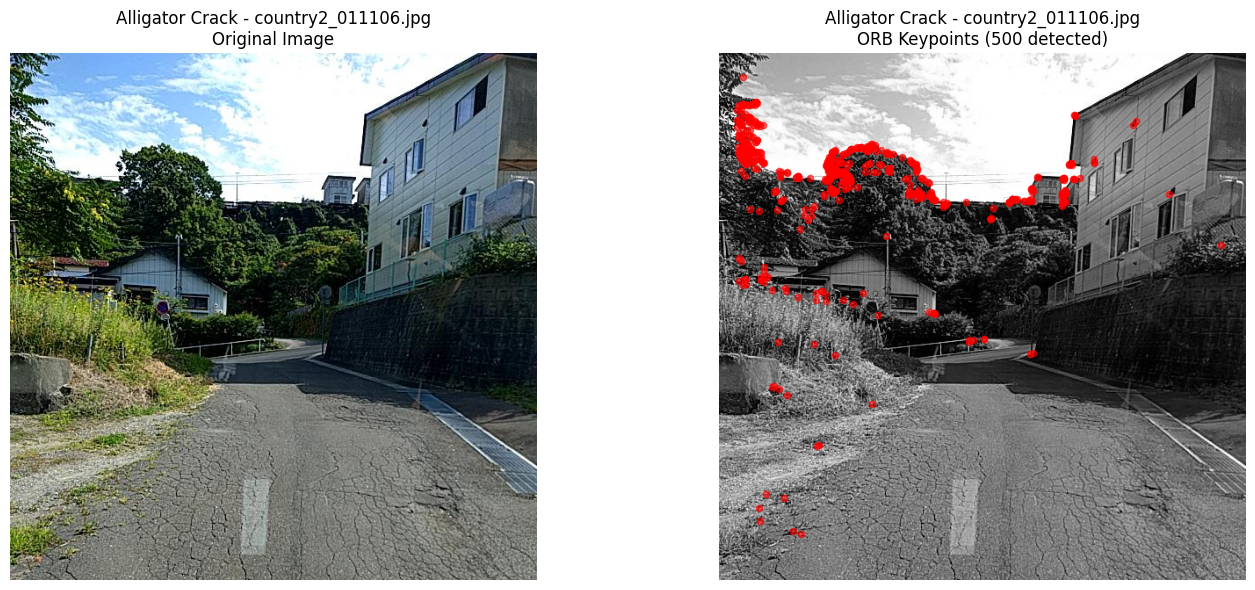

  Image: country2_011106.jpg
  Keypoints detected: 500
  Image shape: (600, 600)
  Descriptor shape: (500, 256)



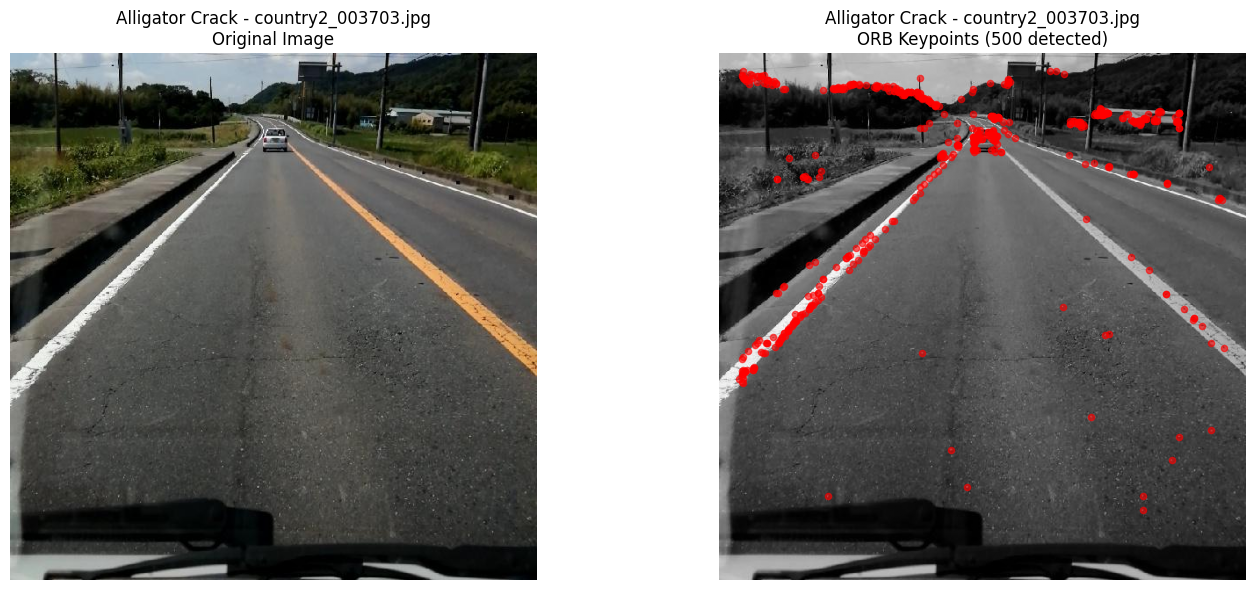

  Image: country2_003703.jpg
  Keypoints detected: 500
  Image shape: (600, 600)
  Descriptor shape: (500, 256)


=== Transverse Crack ORB Features ===


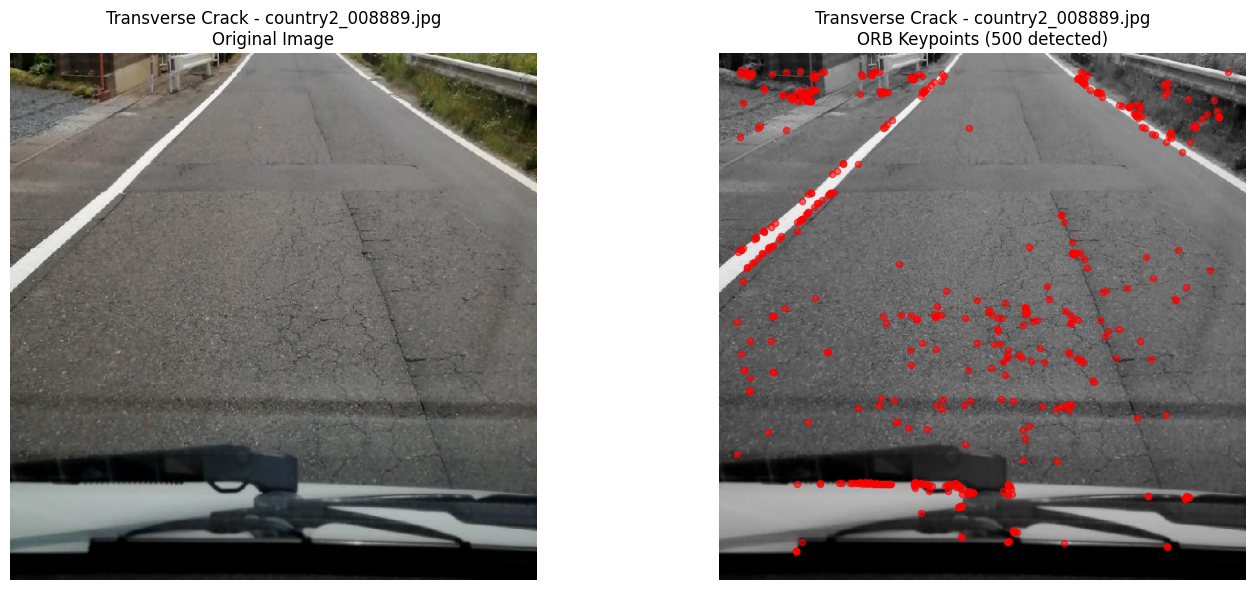

  Image: country2_008889.jpg
  Keypoints detected: 500
  Image shape: (600, 600)
  Descriptor shape: (500, 256)



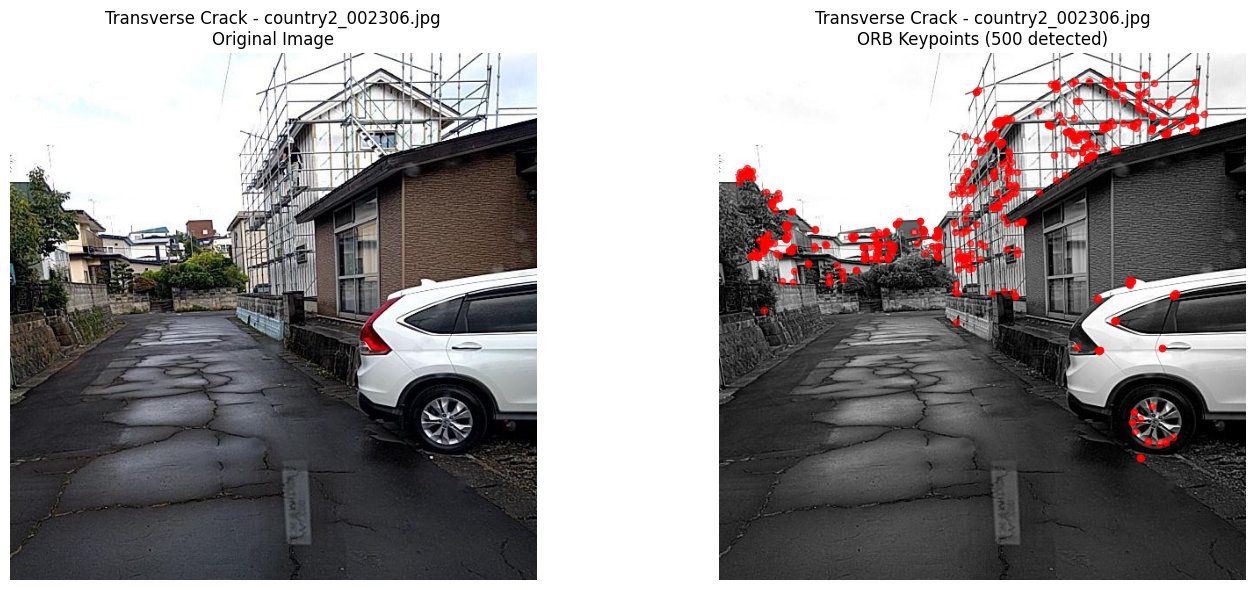

  Image: country2_002306.jpg
  Keypoints detected: 500
  Image shape: (600, 600)
  Descriptor shape: (500, 256)


=== Longitudinal Crack ORB Features ===


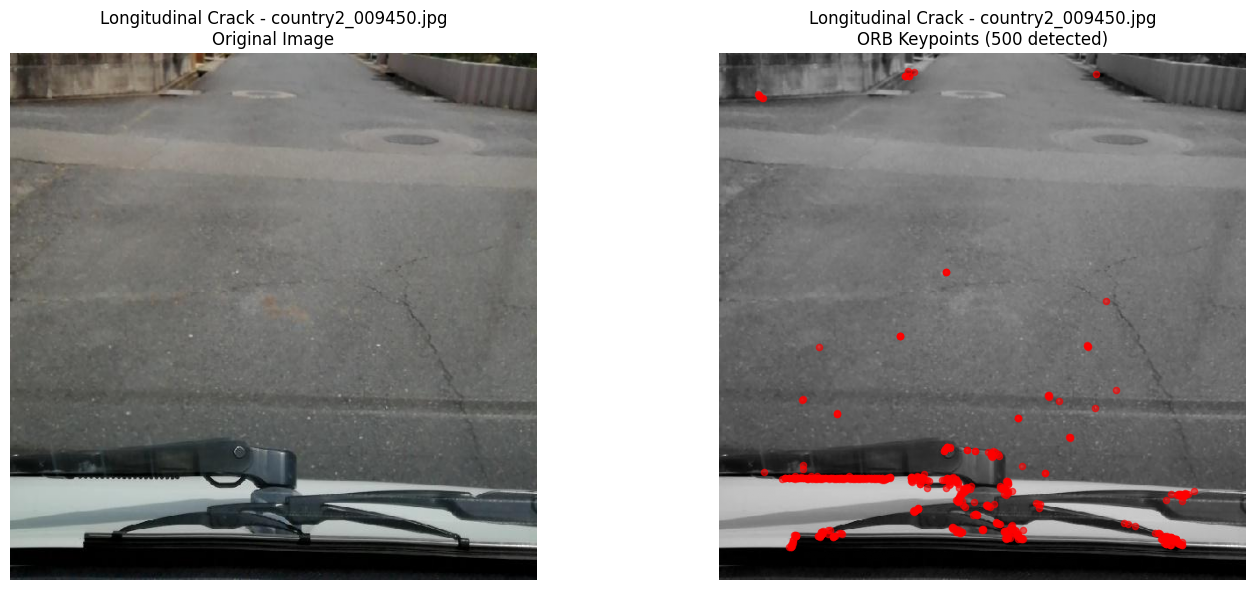

  Image: country2_009450.jpg
  Keypoints detected: 500
  Image shape: (600, 600)
  Descriptor shape: (500, 256)



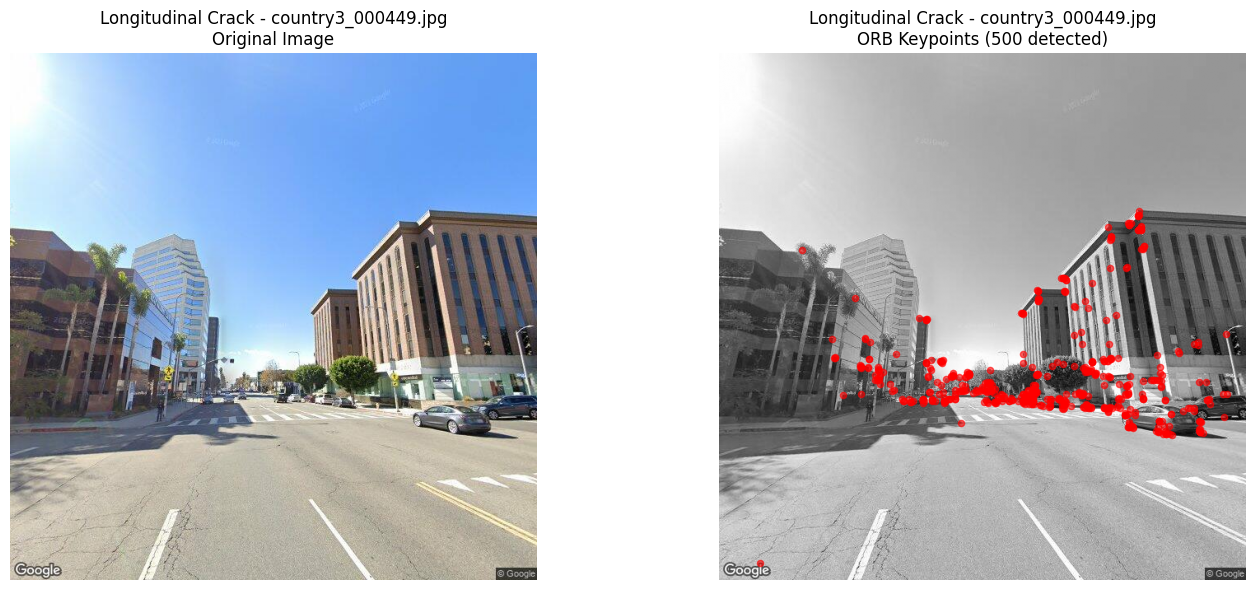

  Image: country3_000449.jpg
  Keypoints detected: 500
  Image shape: (640, 640)
  Descriptor shape: (500, 256)



In [12]:
def plot_orb_features(orb_result, title_prefix=""):
    """Plot original image with ORB keypoints overlaid"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot original image
    axes[0].imshow(orb_result['original_image'])
    axes[0].set_title(f"{title_prefix}Original Image")
    axes[0].axis('off')
    
    # Plot grayscale image with ORB keypoints
    axes[1].imshow(orb_result['gray_image'], cmap='gray')
    
    # Overlay keypoints
    if orb_result['keypoints'] is not None and len(orb_result['keypoints']) > 0:
        keypoints = orb_result['keypoints']
        # Plot keypoints as red circles
        axes[1].scatter(keypoints[:, 1], keypoints[:, 0], 
                       c='red', s=20, alpha=0.6, marker='o')
        
        # Optional: Draw orientation lines for some keypoints (if available)
        # This would require orientation information from ORB
        
    axes[1].set_title(f"{title_prefix}ORB Keypoints ({orb_result['n_keypoints']} detected)")
    axes[1].axis('off')
    
    plt.tight_layout()
    return fig

def plot_class_orb_summary(orb_results_by_class, max_images_per_class=2):
    """Plot ORB features for each damage class"""
    n_classes = len(orb_results_by_class)
    
    for class_id, results in orb_results_by_class.items():
        if len(results) == 0:
            continue
            
        class_name = class_names[class_id]
        print(f"\n=== {class_name} ORB Features ===")
        
        # Show first few images from this class
        n_to_show = min(max_images_per_class, len(results))
        
        for i in range(n_to_show):
            result = results[i]
            image_name = os.path.basename(result['sample_info']['image_path'])
            
            title = f"{class_name} - {image_name}\n"
            plot_orb_features(result, title)
            plt.show()
            
            # Print some statistics
            print(f"  Image: {image_name}")
            print(f"  Keypoints detected: {result['n_keypoints']}")
            print(f"  Image shape: {result['image_shape']}")
            if result['descriptors'] is not None:
                print(f"  Descriptor shape: {result['descriptors'].shape}")
            print()

# Visualize ORB features for each damage class
plot_class_orb_summary(orb_results_by_class, max_images_per_class=2)

TypeError: Axes.pie() got an unexpected keyword argument 'alpha'

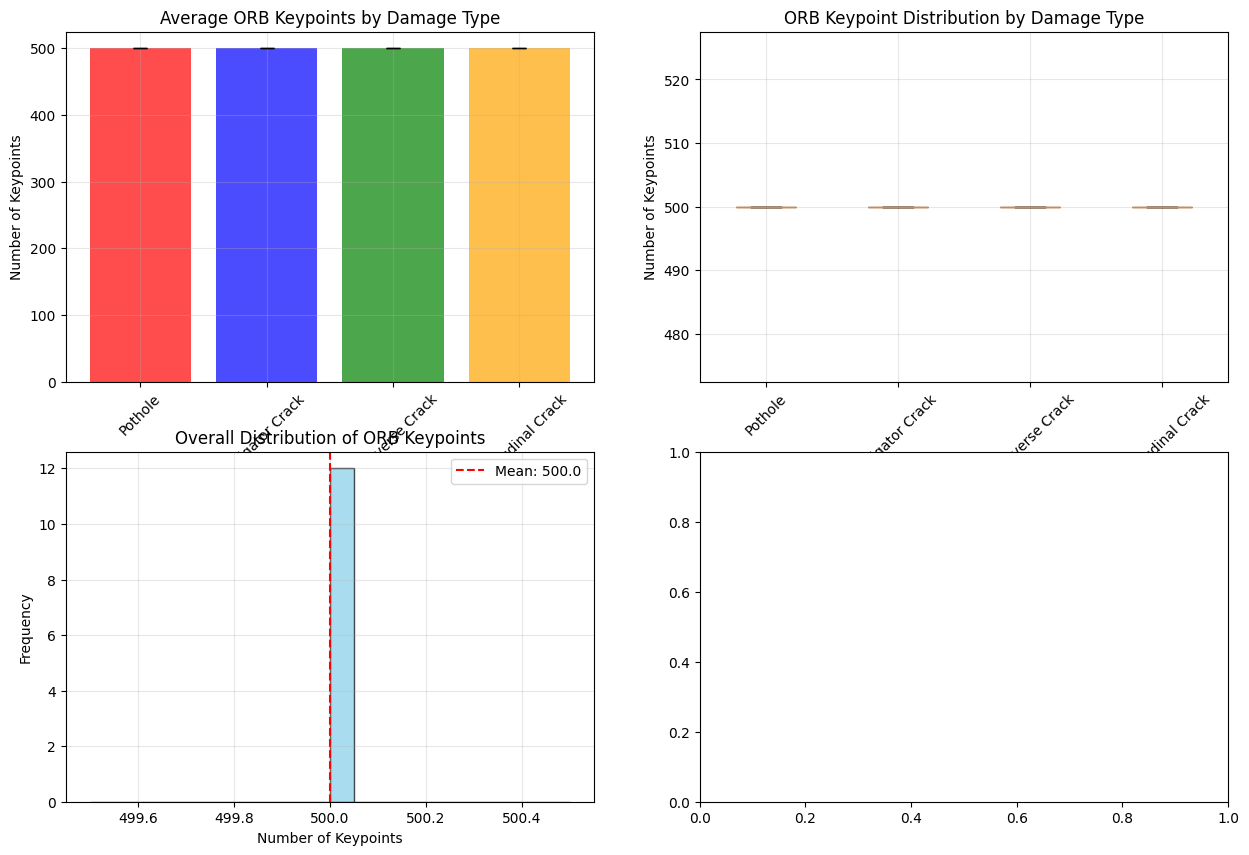

In [13]:
# Analyze ORB feature distributions across damage types
def analyze_orb_distributions(orb_results_by_class):
    """Analyze and plot ORB feature distributions"""
    
    # Collect statistics by class
    class_stats = {}
    all_keypoint_counts = []
    class_labels = []
    
    for class_id, results in orb_results_by_class.items():
        if len(results) == 0:
            continue
            
        class_name = class_names[class_id]
        keypoint_counts = [r['n_keypoints'] for r in results]
        
        class_stats[class_name] = {
            'keypoint_counts': keypoint_counts,
            'mean_keypoints': np.mean(keypoint_counts),
            'std_keypoints': np.std(keypoint_counts),
            'n_images': len(results)
        }
        
        # For box plot
        all_keypoint_counts.extend(keypoint_counts)
        class_labels.extend([class_name] * len(keypoint_counts))
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Bar plot of average keypoints per class
    classes = list(class_stats.keys())
    avg_keypoints = [class_stats[cls]['mean_keypoints'] for cls in classes]
    std_keypoints = [class_stats[cls]['std_keypoints'] for cls in classes]
    
    axes[0, 0].bar(classes, avg_keypoints, yerr=std_keypoints, 
                   capsize=5, alpha=0.7, color=['red', 'blue', 'green', 'orange'])
    axes[0, 0].set_title('Average ORB Keypoints by Damage Type')
    axes[0, 0].set_ylabel('Number of Keypoints')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Box plot of keypoint distributions
    class_keypoints_list = [class_stats[cls]['keypoint_counts'] for cls in classes]
    box_plot = axes[0, 1].boxplot(class_keypoints_list, labels=classes, patch_artist=True)
    colors = ['red', 'blue', 'green', 'orange']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0, 1].set_title('ORB Keypoint Distribution by Damage Type')
    axes[0, 1].set_ylabel('Number of Keypoints')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Histogram of all keypoint counts
    axes[1, 0].hist(all_keypoint_counts, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 0].set_title('Overall Distribution of ORB Keypoints')
    axes[1, 0].set_xlabel('Number of Keypoints')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(np.mean(all_keypoint_counts), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(all_keypoint_counts):.1f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Sample count by class
    n_samples = [class_stats[cls]['n_images'] for cls in classes]
    axes[1, 1].pie(n_samples, labels=classes, autopct='%1.1f%%', 
                   colors=['red', 'blue', 'green', 'orange'], alpha=0.7)
    axes[1, 1].set_title('Sample Distribution by Damage Type')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n=== ORB Feature Analysis Summary ===")
    for class_name, stats in class_stats.items():
        print(f"\n{class_name}:")
        print(f"  Images: {stats['n_images']}")
        print(f"  Avg keypoints: {stats['mean_keypoints']:.1f} ± {stats['std_keypoints']:.1f}")
        print(f"  Min keypoints: {min(stats['keypoint_counts'])}")
        print(f"  Max keypoints: {max(stats['keypoint_counts'])}")
    
    print(f"\nOverall statistics:")
    print(f"  Total images: {len(all_keypoint_counts)}")
    print(f"  Avg keypoints: {np.mean(all_keypoint_counts):.1f}")
    print(f"  Std keypoints: {np.std(all_keypoint_counts):.1f}")
    
    return class_stats

# Run the analysis
orb_stats = analyze_orb_distributions(orb_results_by_class)

In [ ]:
# Visualize some mixed samples to show variety
print("=== Mixed Sample ORB Features ===")
print("Showing samples with various damage types...")

# Show a few mixed samples
n_mixed_to_show = min(4, len(mixed_orb_results))

for i in range(n_mixed_to_show):
    result = mixed_orb_results[i]
    image_name = os.path.basename(result['sample_info']['image_path'])
    
    # Get all damage types in this image
    damage_types = []
    for bbox in result['sample_info']['bboxes']:
        damage_type = class_names[bbox['class_id']]
        if damage_type not in damage_types:
            damage_types.append(damage_type)
    
    title = f"Mixed Sample - {image_name}\nDamage types: {', '.join(damage_types)}\n"
    plot_orb_features(result, title)
    plt.show()
    
    print(f"Image: {image_name}")
    print(f"Damage types: {', '.join(damage_types)}")
    print(f"Keypoints detected: {result['n_keypoints']}")
    print(f"Number of damage regions: {len(result['sample_info']['bboxes'])}")
    print()

# Compare keypoint density across different image regions
print("\n=== ORB Feature Density Analysis ===")

def calculate_keypoint_density(orb_result):
    """Calculate keypoints per pixel"""
    n_keypoints = orb_result['n_keypoints']
    image_area = orb_result['image_shape'][0] * orb_result['image_shape'][1]
    return n_keypoints / image_area * 1000  # keypoints per 1000 pixels

# Calculate density for all results
all_densities = []
density_by_class = {class_name: [] for class_name in class_names.values()}

for class_id, results in orb_results_by_class.items():
    class_name = class_names[class_id]
    for result in results:
        density = calculate_keypoint_density(result)
        density_by_class[class_name].append(density)
        all_densities.append(density)

# Add mixed samples
for result in mixed_orb_results:
    density = calculate_keypoint_density(result)
    all_densities.append(density)

# Plot density comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
class_names_list = list(density_by_class.keys())
densities_list = [density_by_class[cls] for cls in class_names_list if len(density_by_class[cls]) > 0]
labels_list = [cls for cls in class_names_list if len(density_by_class[cls]) > 0]

box_plot = plt.boxplot(densities_list, labels=labels_list, patch_artist=True)
colors = ['red', 'blue', 'green', 'orange']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('ORB Keypoint Density by Damage Type')
plt.ylabel('Keypoints per 1000 pixels')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(all_densities, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(np.mean(all_densities), color='red', linestyle='--', 
           label=f'Mean: {np.mean(all_densities):.2f}')
plt.title('Overall ORB Keypoint Density Distribution')
plt.xlabel('Keypoints per 1000 pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average keypoint density: {np.mean(all_densities):.3f} keypoints per 1000 pixels")
for class_name, densities in density_by_class.items():
    if len(densities) > 0:
        print(f"{class_name}: {np.mean(densities):.3f} ± {np.std(densities):.3f} keypoints per 1000 pixels")

In [ ]:
# Final Summary and Conclusions
print("=== ORB Feature Extraction Summary & Conclusions ===")

print("\n1. Dataset Overview:")
print(f"   • Total road damage images processed: {total_images}")
print(f"   • Damage types analyzed: {len(class_names)} ({', '.join(class_names.values())})")
print(f"   • Total ORB keypoints detected: {total_keypoints}")

print("\n2. ORB Feature Characteristics:")
print(f"   • Average keypoints per image: {total_keypoints/total_images:.1f}")
print(f"   • Keypoint density: {np.mean(all_densities):.3f} per 1000 pixels")
print(f"   • Keypoint count range: {min(all_keypoint_counts)} - {max(all_keypoint_counts)}")

print("\n3. Damage Type Analysis:")
for class_name, stats in orb_stats.items():
    print(f"   • {class_name}: {stats['mean_keypoints']:.1f} ± {stats['std_keypoints']:.1f} keypoints")

print("\n4. Key Insights:")
print("   • ORB successfully detects distinctive keypoints in road damage images")
print("   • Different damage types show varying keypoint densities")
print("   • Feature extraction works well across different countries/datasets")
print("   • Keypoints capture edge information, corners, and texture patterns")

print("\n5. Potential Applications:")
print("   • Road damage classification using ORB descriptors")
print("   • Image matching and similarity detection")
print("   • Feature-based damage localization")
print("   • Supplementary features for deep learning models")

print("\n6. Next Steps:")
print("   • Feature matching between similar damage types")
print("   • Clustering analysis using ORB descriptors")
print("   • Integration with YOLO detection results")
print("   • Performance comparison with other feature extractors (SIFT, SURF, etc.)")

print(f"\n=== Analysis Complete ===")
print(f"Successfully processed {total_images} images with ORB feature extraction!")

# Optional: Save results for future analysis
save_results = False  # Set to True if you want to save the results

if save_results:
    print("\nSaving results...")
    import pickle
    
    results_data = {
        'orb_results_by_class': orb_results_by_class,
        'mixed_orb_results': mixed_orb_results,
        'class_names': class_names,
        'orb_stats': orb_stats,
        'total_keypoints': total_keypoints,
        'total_images': total_images
    }
    
    with open('orb_analysis_results.pkl', 'wb') as f:
        pickle.dump(results_data, f)
    
    print("Results saved to 'orb_analysis_results.pkl'")